# Benchmark 1/N — Carteira Igualmente Ponderada
**TCC: Moderna Teoria das Carteiras no Mercado de Ações Brasileiro**
**Autor:** Pedro Augusto Pinheiro Reis | UFG — Ciências Contábeis

---
## Objetivo
Calcular o backtest da carteira *naive* igualmente ponderada (1/N) como benchmark de comparação com as estratégias de otimização.
DeMiguel, Garlappi & Uppal (2009) demonstraram que a 1/N supera carteiras otimizadas *out-of-sample* na maioria dos mercados.
Neste notebook calculamos **duas versões** para o mesmo universo de 135 ativos:
- **1/N Buy-and-Hold**: alocação inicial igual e nunca rebalanceada
- **1/N Mensal**: rebalanceamento de volta a pesos iguais no último pregão de cada mês

O período *out-of-sample* é **janeiro de 2015 a dezembro de 2025** (2.729 pregões),
idêntico ao utilizado pelas estratégias L1 e BL+LSTM.

In [1]:
# ============================================================
# CÉLULA 1 — INSTALAÇÕES E IMPORTAÇÕES
# ============================================================
%pip install pandas numpy scipy matplotlib seaborn openpyxl --quiet

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

print('✅ Dependências carregadas.')

Note: you may need to restart the kernel to use updated packages.
✅ Dependências carregadas.


In [2]:
# ============================================================
# CÉLULA 2 — CONFIGURAÇÃO DE CAMINHOS
# ============================================================
# AJUSTE conforme seu ambiente

PASTA_DADOS      = r'C:\VSCodeWorkspace\TCC_Final\data'
PASTA_RESULTADOS = r'C:\VSCodeWorkspace\TCC_Final\results\benchmark_1n'
os.makedirs(PASTA_RESULTADOS, exist_ok=True)

ARQUIVO_PRECOS = os.path.join(PASTA_DADOS, 'lista_economatica_dados_Jan_2010_Dezembro_2025.csv')
ARQUIVO_CDI    = os.path.join(PASTA_DADOS, 'CDI_2010_2026.xlsx')
ARQUIVO_IBOV   = os.path.join(PASTA_DADOS, 'IBOV_2010_2026.xlsx')
ARQUIVO_SELIC  = os.path.join(PASTA_DADOS, 'SELIC_2010_2026.xlsx')

# ── Parâmetros ──────────────────────────────────────────────
COBERTURA_MINIMA = 0.95          # filtro de ativos (>=95% dos pregões)
INICIO_OOS       = '2015-01-01'  # início do período out-of-sample
CUSTO_TRANS      = 0.005         # 0,5% por lado rebalanceado (igual às estratégias L1)
ALPHA            = 0.05          # nível de significância

print(f'Pasta de dados:   {PASTA_DADOS}')
print(f'Pasta resultados: {PASTA_RESULTADOS}')
print(f'Início OOS: {INICIO_OOS}')
print(f'Custo transacional: {CUSTO_TRANS:.1%}/lado')

Pasta de dados:   C:\VSCodeWorkspace\TCC_Final\data
Pasta resultados: C:\VSCodeWorkspace\TCC_Final\results\benchmark_1n
Início OOS: 2015-01-01
Custo transacional: 0.5%/lado


In [3]:
# ============================================================
# CÉLULA 3 — CARREGAMENTO DOS DADOS
# ============================================================

print('Carregando dados...')

# ── Preços ──────────────────────────────────────────────────
df_raw = pd.read_csv(ARQUIVO_PRECOS, sep=';', decimal=',', encoding='utf-8')
df_raw.rename(columns={df_raw.columns[0]: 'Data'}, inplace=True)
df_raw['Data'] = pd.to_datetime(df_raw['Data'], dayfirst=True, errors='coerce')
df_raw = df_raw.dropna(subset=['Data']).set_index('Data').sort_index()
df_raw = df_raw.apply(pd.to_numeric, errors='coerce')

# Filtro >=95% de cobertura
cobertura  = 1 - df_raw.isna().mean()
ATIVOS     = sorted(cobertura[cobertura >= COBERTURA_MINIMA].index.tolist())
df_precos  = df_raw[ATIVOS].copy().ffill().bfill()

print(f'  Ativos na amostra: {len(ATIVOS)}')
print(f'  Período: {df_precos.index[0].date()} → {df_precos.index[-1].date()}')

# ── CDI ─────────────────────────────────────────────────────
df_cdi = pd.read_excel(ARQUIVO_CDI, parse_dates=['Data']).set_index('Data').sort_index()
df_cdi.columns = ['CDI']

# ── IBOV ────────────────────────────────────────────────────
df_ibov = pd.read_excel(ARQUIVO_IBOV, parse_dates=['Data']).set_index('Data').sort_index()
df_ibov.columns = ['IBOV']

# ── SELIC ───────────────────────────────────────────────────
df_selic = pd.read_excel(ARQUIVO_SELIC, parse_dates=['Data']).set_index('Data').sort_index()
df_selic.columns = ['SELIC']

print(f'  CDI carregado: {len(df_cdi)} obs | média {df_cdi["CDI"].mean():.4%}/dia')
print(f'  IBOV carregado: {len(df_ibov)} obs')
print('\n✅ Dados carregados.')

Carregando dados...
  Ativos na amostra: 135
  Período: 2010-01-04 → 2025-12-30
  CDI carregado: 4050 obs | média 0.0370%/dia
  IBOV carregado: 4012 obs

✅ Dados carregados.


In [4]:
# ============================================================
# CÉLULA 4 — RETORNOS E PERÍODO OUT-OF-SAMPLE
# ============================================================

# Retornos simples diários (para backtesting e otimização)
ret_simples = df_precos.pct_change().dropna(how='all')

# Recorte out-of-sample
ret_oos  = ret_simples.loc[INICIO_OOS:]
prec_oos = df_precos.loc[INICIO_OOS:]

# Benchmarks alinhados ao período OOS
cdi_oos  = df_cdi.reindex(ret_oos.index).ffill()['CDI']
ibov_oos = df_ibov.reindex(ret_oos.index).ffill()['IBOV']
ret_ibov = ibov_oos.pct_change().dropna()

N = len(ATIVOS)
T = len(ret_oos)

print(f'Período OOS: {ret_oos.index[0].date()} → {ret_oos.index[-1].date()}')
print(f'Pregões: {T} | Ativos: {N}')
print(f'CDI OOS acumulado: {(1 + cdi_oos).prod() - 1:.2%}')
print(f'IBOV OOS acumulado: {(1 + ret_ibov).cumprod().iloc[-1] - 1:.2%}')

Período OOS: 2015-01-02 → 2025-12-30
Pregões: 2729 | Ativos: 135
CDI OOS acumulado: 173.64%
IBOV OOS acumulado: 232.13%


In [5]:
# ============================================================
# CÉLULA 5 — FUNÇÃO DE MÉTRICAS DE DESEMPENHO
# ============================================================

def calcular_metricas(serie_retornos, taxa_rf_diaria, nome='Estratégia'):
    """
    Calcula o conjunto completo de métricas de desempenho.
    Entrada: série de retornos diários simples (pd.Series).
    """
    r = serie_retornos.dropna()
    rf = taxa_rf_diaria.reindex(r.index).ffill()
    T  = len(r)

    # ── Retorno ─────────────────────────────────────────────
    curva_capital = (1 + r).cumprod()
    ret_acum = curva_capital.iloc[-1] - 1
    anos     = T / 252
    cagr     = (1 + ret_acum) ** (1 / anos) - 1

    # ── Risco ────────────────────────────────────────────────
    vol_anual = r.std() * np.sqrt(252)

    # Downside deviation (abaixo do CDI diário)
    excess_r = r - rf
    downside = excess_r[excess_r < 0]
    downside_std = downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan

    # ── Índices ──────────────────────────────────────────────
    rf_anual = (1 + rf.mean()) ** 252 - 1
    sharpe   = (cagr - rf_anual) / vol_anual if vol_anual > 0 else np.nan
    sortino  = (cagr - rf_anual) / downside_std if downside_std and downside_std > 0 else np.nan

    # ── Maximum Drawdown ─────────────────────────────────────
    rolling_max = curva_capital.cummax()
    drawdown    = (curva_capital - rolling_max) / rolling_max
    mdd         = drawdown.min()
    data_mdd    = drawdown.idxmin()

    # ── VaR e CVaR histórico (95%) ───────────────────────────
    var_95  = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()

    # ── Calmar Ratio ─────────────────────────────────────────
    calmar = cagr / abs(mdd) if mdd != 0 else np.nan

    return {
        'Nome'            : nome,
        'Retorno_Acum'    : ret_acum,
        'CAGR'            : cagr,
        'Vol_Anual'       : vol_anual,
        'Sharpe'          : sharpe,
        'Sortino'         : sortino,
        'MDD'             : mdd,
        'Data_MDD'        : data_mdd,
        'VaR_95'          : var_95,
        'CVaR_95'         : cvar_95,
        'Calmar'          : calmar,
        'N_pregoes'       : T,
        'curva_capital'   : curva_capital,
        'drawdown'        : drawdown,
    }

print('✅ Função de métricas definida.')

✅ Função de métricas definida.


In [6]:
# ============================================================
# CÉLULA 6 — ESTRATÉGIA 1: 1/N BUY-AND-HOLD
# ============================================================
# Alocação inicial de 1/N em cada ativo no primeiro dia OOS.
# Os pesos derivam diretamente da valorização dos ativos —
# não há rebalanceamento. Turnover = 0 após o dia inicial.

print('Calculando 1/N Buy-and-Hold...')

# Pesos iniciais
w0_bh = np.ones(N) / N

# Simulação diária: os pesos evoluem com os retornos (sem forçar de volta a 1/N)
ret_matriz = ret_oos[ATIVOS].fillna(0).values      # (T, N)
capital    = np.zeros(T)
w_atual    = w0_bh.copy()

for t in range(T):
    r_dia     = ret_matriz[t]
    ret_port  = np.dot(w_atual, r_dia)
    capital[t] = (capital[t-1] if t > 0 else 1.0) * (1 + ret_port)
    # Atualizar pesos pela valorização (sem rebalancear)
    w_atual   = w_atual * (1 + r_dia)
    w_atual   = w_atual / w_atual.sum()  # normalizar para soma=1

ret_bh = pd.Series(
    (capital / np.concatenate([[1.0], capital[:-1]])) - 1,
    index=ret_oos.index
)

m_bh = calcular_metricas(ret_bh, cdi_oos, '1/N Buy-and-Hold')
print(f'  Retorno acumulado: {m_bh["Retorno_Acum"]:.2%}')
print(f'  CAGR:              {m_bh["CAGR"]:.2%}')
print(f'  Sharpe:            {m_bh["Sharpe"]:.4f}')
print(f'  MDD:               {m_bh["MDD"]:.2%}')
print('✅ 1/N Buy-and-Hold calculado.')

Calculando 1/N Buy-and-Hold...
  Retorno acumulado: 340.01%
  CAGR:              14.66%
  Sharpe:            0.2333
  MDD:               -48.90%
✅ 1/N Buy-and-Hold calculado.


In [7]:
# ============================================================
# CÉLULA 7 — ESTRATÉGIA 2: 1/N COM REBALANCEAMENTO MENSAL
# ============================================================
# No último pregão de cada mês, os pesos são forçados de volta
# a 1/N. O custo transacional é aplicado sobre o turnover
# realizado — mesma metodologia das estratégias L1.
#
# Nota metodológica: o shift(1) é aplicado implicitamente —
# os pesos decididos no pregão t são aplicados no retorno t+1.

print('Calculando 1/N com rebalanceamento mensal...')

# Datas de rebalanceamento: último pregão de cada mês
datas_rebal = ret_oos.resample('ME').last().index
datas_rebal = datas_rebal[datas_rebal <= ret_oos.index[-1]]

w_alvo       = np.ones(N) / N   # pesos-alvo fixos
ret_matriz   = ret_oos[ATIVOS].fillna(0).values
datas_idx    = ret_oos.index

capital_m      = np.zeros(T)
w_atual_m      = w_alvo.copy()
historico_pesos= []
historico_turn = []
rebal_set      = set(datas_rebal)

for t, data in enumerate(datas_idx):

    # Rebalancear se for último pregão do mês
    if data in rebal_set:
        # Turnover = soma das diferenças absolutas (unilateral)
        turnover = np.sum(np.abs(w_alvo - w_atual_m)) / 2
        custo    = turnover * CUSTO_TRANS
        w_atual_m = w_alvo.copy()
    else:
        custo    = 0.0
        turnover = 0.0

    r_dia     = ret_matriz[t]
    ret_port  = np.dot(w_atual_m, r_dia) - custo
    capital_m[t] = (capital_m[t-1] if t > 0 else 1.0) * (1 + ret_port)

    # Deixar os pesos derivar até o próximo rebalanceamento
    w_atual_m = w_atual_m * (1 + r_dia)
    w_atual_m = w_atual_m / w_atual_m.sum()

    historico_pesos.append(w_atual_m.copy())
    historico_turn.append(turnover)

ret_1n = pd.Series(
    (capital_m / np.concatenate([[1.0], capital_m[:-1]])) - 1,
    index=datas_idx
)

turn_serie = pd.Series(historico_turn, index=datas_idx)
turn_mensal = turn_serie.resample('ME').sum()
turn_medio  = turn_mensal[turn_mensal > 0].mean()

m_1n = calcular_metricas(ret_1n, cdi_oos, '1/N Rebalanceamento Mensal')
print(f'  Retorno acumulado: {m_1n["Retorno_Acum"]:.2%}')
print(f'  CAGR:              {m_1n["CAGR"]:.2%}')
print(f'  Sharpe:            {m_1n["Sharpe"]:.4f}')
print(f'  MDD:               {m_1n["MDD"]:.2%}')
print(f'  Turnover médio (meses com rebalanceamento): {turn_medio:.2%}')
print('✅ 1/N Mensal calculado.')

Calculando 1/N com rebalanceamento mensal...
  Retorno acumulado: 267.69%
  CAGR:              12.78%
  Sharpe:            0.1283
  MDD:               -51.47%
  Turnover médio (meses com rebalanceamento): 5.08%
✅ 1/N Mensal calculado.


In [8]:
# ============================================================
# CÉLULA 8 — BENCHMARKS: IBOVESPA E CDI
# ============================================================

# IBOV
ret_ibov_alinhado = ret_ibov.reindex(ret_oos.index).fillna(0)
m_ibov = calcular_metricas(ret_ibov_alinhado, cdi_oos, 'IBOVESPA')

# CDI (como série de retornos diários)
m_cdi = calcular_metricas(cdi_oos, cdi_oos, 'CDI')

print(f'IBOV — Retorno: {m_ibov["Retorno_Acum"]:.2%} | Sharpe: {m_ibov["Sharpe"]:.4f} | MDD: {m_ibov["MDD"]:.2%}')
print(f'CDI  — Retorno: {m_cdi["Retorno_Acum"]:.2%}')

IBOV — Retorno: 232.13% | Sharpe: 0.0849 | MDD: -46.82%
CDI  — Retorno: 173.64%


In [9]:
# ============================================================
# CÉLULA 9 — TABELA COMPARATIVA COMPLETA
# ============================================================

METRICAS_EXIBIR = [
    ('Retorno_Acum', 'Retorno Acumulado', '{:.2%}'),
    ('CAGR',         'CAGR',             '{:.2%}'),
    ('Vol_Anual',    'Volatilidade Anual','{:.2%}'),
    ('Sharpe',       'Índice de Sharpe',  '{:.4f}'),
    ('Sortino',      'Índice de Sortino', '{:.4f}'),
    ('MDD',          'Max. Drawdown',     '{:.2%}'),
    ('VaR_95',       'VaR Diário 95%',    '{:.4%}'),
    ('CVaR_95',      'CVaR Diário 95%',   '{:.4%}'),
    ('Calmar',       'Calmar Ratio',      '{:.4f}'),
]

resultados = [m_bh, m_1n, m_ibov, m_cdi]

# Adicionar turnover manual (não calculado na função)
extras = {
    '1/N Buy-and-Hold'              : 0.0,
    '1/N Rebalanceamento Mensal'    : turn_medio,
    'IBOVESPA'                      : None,
    'CDI'                           : None,
}

rows = []
for m in resultados:
    row = {'Estratégia': m['Nome']}
    for col, label, fmt in METRICAS_EXIBIR:
        v = m.get(col, np.nan)
        row[label] = fmt.format(v) if (v is not None and not (isinstance(v, float) and np.isnan(v))) else '—'
    turn = extras[m['Nome']]
    row['Turnover Médio'] = f'{turn:.2%}' if turn is not None else '—'
    rows.append(row)

df_tabela = pd.DataFrame(rows).set_index('Estratégia')

print('=' * 80)
print('TABELA — Desempenho das Carteiras 1/N (jan/2015 – dez/2025)')
print('=' * 80)
print(df_tabela.to_string())

# Exportar
df_tabela.to_csv(os.path.join(PASTA_RESULTADOS, 'tabela_desempenho_1N.csv'), sep=';', decimal=',')
print(f'\n✅ Tabela exportada.')

TABELA — Desempenho das Carteiras 1/N (jan/2015 – dez/2025)
                           Retorno Acumulado    CAGR Volatilidade Anual Índice de Sharpe Índice de Sortino Max. Drawdown VaR Diário 95% CVaR Diário 95% Calmar Ratio Turnover Médio
Estratégia                                                                                                                                                                         
1/N Buy-and-Hold                     340.01%  14.66%             21.09%           0.2333            0.2831       -48.90%       -1.8410%        -3.0324%       0.2998          0.00%
1/N Rebalanceamento Mensal           267.69%  12.78%             23.65%           0.1283            0.1579       -51.47%       -2.0364%        -3.3325%       0.2482          5.08%
IBOVESPA                             232.13%  11.72%             23.32%           0.0849            0.1111       -46.82%       -2.1724%        -3.2815%       0.2504              —
CDI                                  173

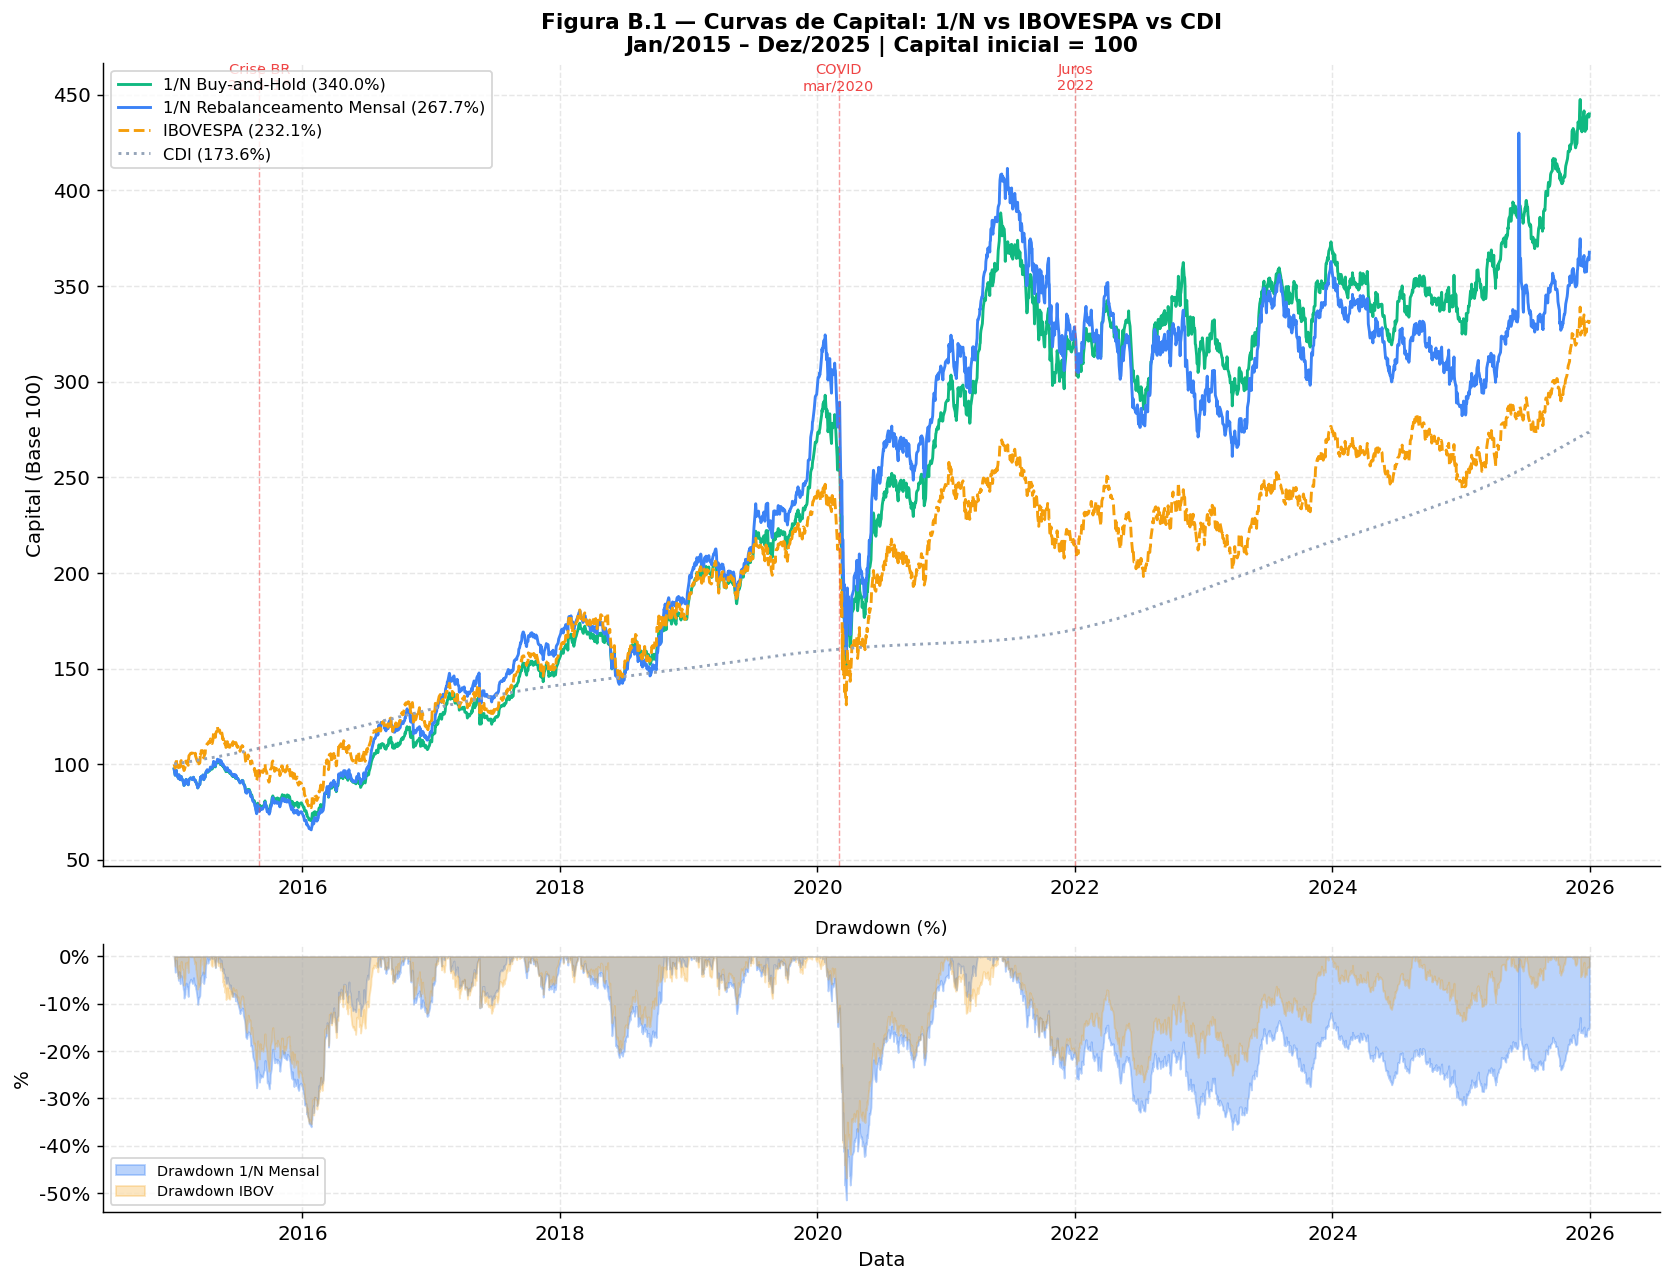

✅ Figura B.1 exportada.


In [10]:
# ============================================================
# CÉLULA 10 — FIGURA 1: CURVAS DE CAPITAL
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(13, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1, ax2 = axes

# Paleta
cores = {
    '1/N Buy-and-Hold'           : '#10b981',
    '1/N Rebalanceamento Mensal' : '#3b82f6',
    'IBOVESPA'                   : '#f59e0b',
    'CDI'                        : '#94a3b8',
}
estilos = {
    '1/N Buy-and-Hold'           : '-',
    '1/N Rebalanceamento Mensal' : '-',
    'IBOVESPA'                   : '--',
    'CDI'                        : ':',
}

# ── Curvas de capital ──
for m in resultados:
    curva = m['curva_capital']
    ax1.plot(curva.index, curva.values * 100,
             label=f"{m['Nome']} ({m['Retorno_Acum']:.1%})",
             color=cores[m['Nome']], ls=estilos[m['Nome']], lw=1.6)

# Marcadores de eventos
eventos = {
    'Crise BR\n2015–16': '2015-09-01',
    'COVID\nmar/2020'  : '2020-03-01',
    'Juros\n2022'      : '2022-01-01',
}
for label, data in eventos.items():
    ax1.axvline(pd.Timestamp(data), color='#ef4444', lw=0.8, alpha=0.5, ls='--')
    ax1.text(pd.Timestamp(data), ax1.get_ylim()[1] if ax1.get_ylim()[1] > 100 else 500,
             label, fontsize=8, color='#ef4444', ha='center', va='top')

ax1.set_title('Figura B.1 — Curvas de Capital: 1/N vs IBOVESPA vs CDI\n'
              'Jan/2015 – Dez/2025 | Capital inicial = 100',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Capital (Base 100)')
ax1.legend(loc='upper left', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

# ── Drawdown da 1/N Mensal ──
dd = m_1n['drawdown'] * 100
ax2.fill_between(dd.index, dd.values, 0,
                 color='#3b82f6', alpha=0.35, label='Drawdown 1/N Mensal')
dd_ibov = m_ibov['drawdown'] * 100
ax2.fill_between(dd_ibov.index, dd_ibov.values, 0,
                 color='#f59e0b', alpha=0.25, label='Drawdown IBOV')

ax2.set_title('Drawdown (%)', fontsize=10)
ax2.set_ylabel('%'); ax2.set_xlabel('Data')
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_B1_curva_capital_1N.png'), bbox_inches='tight')
plt.show()
print('✅ Figura B.1 exportada.')

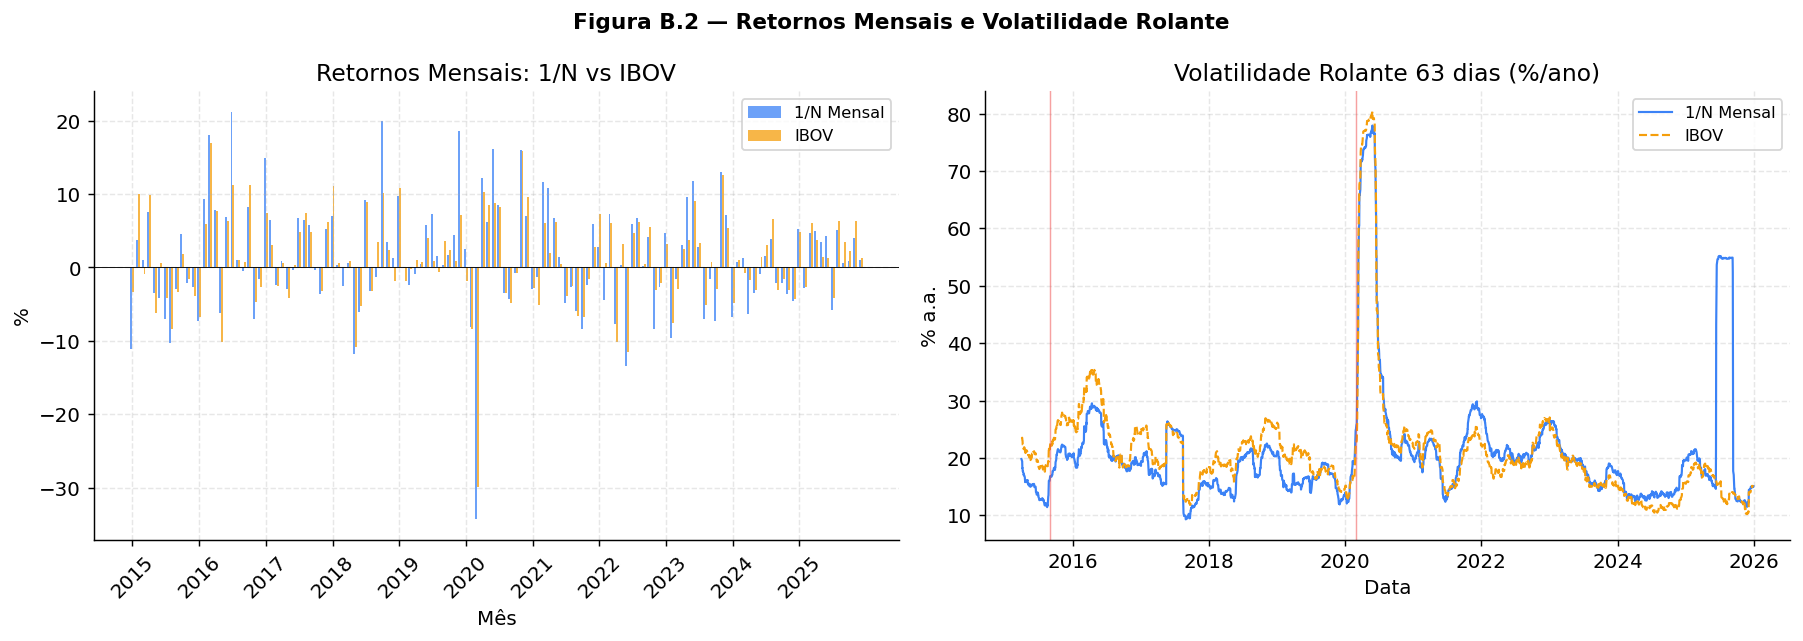

✅ Figura B.2 exportada.


In [11]:
# ============================================================
# CÉLULA 11 — FIGURA 2: RETORNOS MENSAIS E VOLATILIDADE ROLANTE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Retornos mensais acumulados ──
ax = axes[0]
ret_mes_1n   = (1 + ret_1n).resample('ME').prod() - 1
ret_mes_ibov = (1 + ret_ibov_alinhado).resample('ME').prod() - 1

largura   = 0.35
x         = np.arange(len(ret_mes_1n))
ax.bar(x - largura/2, ret_mes_1n.values * 100,
       largura, color='#3b82f6', alpha=0.75, label='1/N Mensal')
ax.bar(x + largura/2, ret_mes_ibov.reindex(ret_mes_1n.index).fillna(0).values * 100,
       largura, color='#f59e0b', alpha=0.75, label='IBOV')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Retornos Mensais: 1/N vs IBOV')
ax.set_ylabel('%'); ax.set_xlabel('Mês')
ax.set_xticks(x[::12])
ax.set_xticklabels([d.strftime('%Y') for d in ret_mes_1n.index[::12]], rotation=45)
ax.legend(fontsize=9)

# ── Volatilidade rolante 63 dias ──
ax2 = axes[1]
vol_1n   = ret_1n.rolling(63).std() * np.sqrt(252) * 100
vol_ibov = ret_ibov_alinhado.rolling(63).std() * np.sqrt(252) * 100

ax2.plot(vol_1n.index,   vol_1n.values,   color='#3b82f6', lw=1.2, label='1/N Mensal')
ax2.plot(vol_ibov.index, vol_ibov.values, color='#f59e0b', lw=1.2, ls='--', label='IBOV')
for data in ['2020-03-01', '2015-09-01']:
    ax2.axvline(pd.Timestamp(data), color='#ef4444', lw=0.8, alpha=0.5)
ax2.set_title('Volatilidade Rolante 63 dias (%/ano)')
ax2.set_ylabel('% a.a.'); ax2.set_xlabel('Data')
ax2.legend(fontsize=9)

plt.suptitle('Figura B.2 — Retornos Mensais e Volatilidade Rolante', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_B2_ret_mensais_vol.png'), bbox_inches='tight')
plt.show()
print('✅ Figura B.2 exportada.')

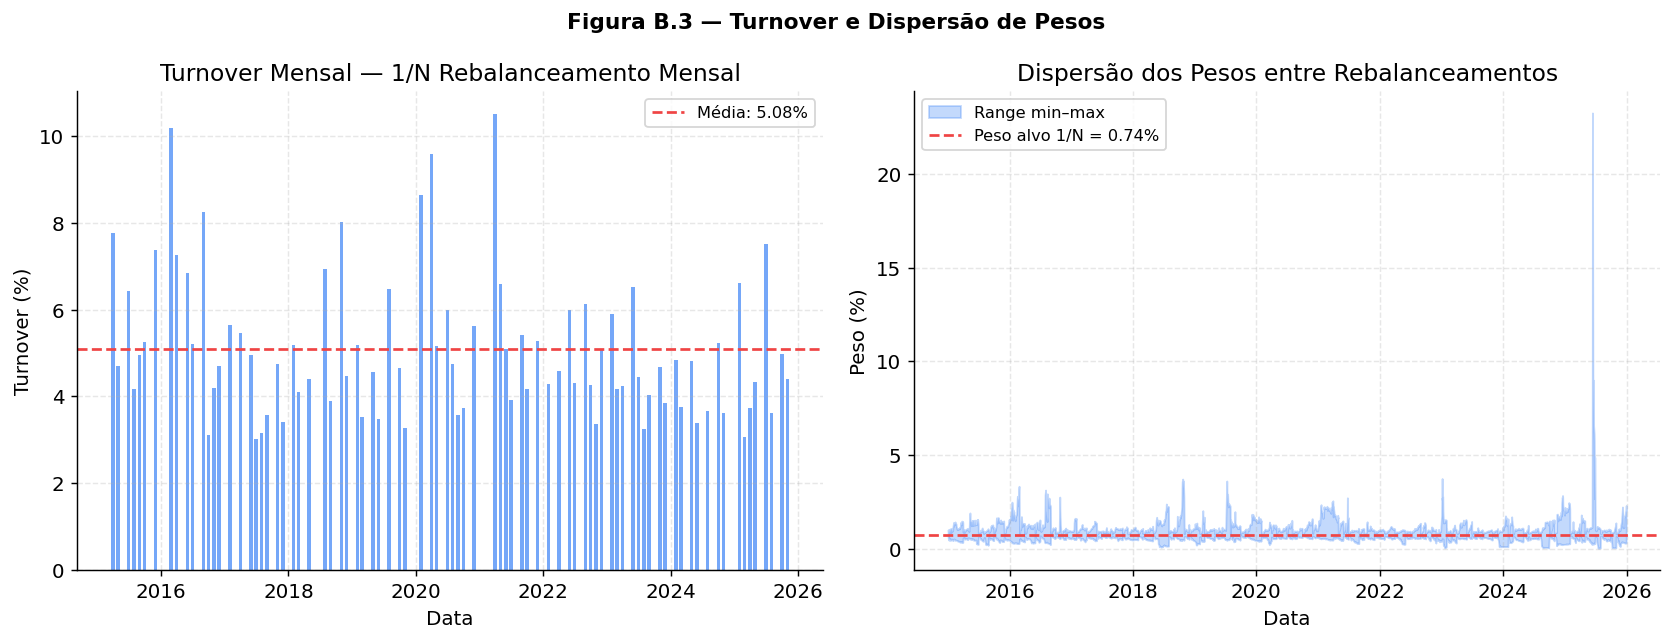

✅ Figura B.3 exportada.


In [12]:
# ============================================================
# CÉLULA 12 — FIGURA 3: ANÁLISE DE TURNOVER E CONCENTRAÇÃO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Turnover mensal da 1/N Mensal ──
ax = axes[0]
turn_plot = turn_mensal[turn_mensal > 0] * 100
ax.bar(turn_plot.index, turn_plot.values,
       color='#3b82f6', alpha=0.7, width=20)
ax.axhline(turn_plot.mean(), color='#ef4444', ls='--',
           label=f'Média: {turn_plot.mean():.2f}%')
ax.set_title('Turnover Mensal — 1/N Rebalanceamento Mensal')
ax.set_ylabel('Turnover (%)')
ax.set_xlabel('Data')
ax.legend(fontsize=9)

# ── Distribuição dos pesos ao longo do tempo (concentração) ──
# Verificar se os pesos derivam muito da igualdade no buy-and-hold
ax2 = axes[1]
pesos_matriz = np.array(historico_pesos)  # (T, N)
# Peso máximo por dia (quanto o mais pesado está acima de 1/N)
peso_max  = pesos_matriz.max(axis=1) * 100
peso_min  = pesos_matriz.min(axis=1) * 100
peso_med  = (1/N) * 100

ax2.fill_between(ret_oos.index, peso_min, peso_max,
                 alpha=0.3, color='#3b82f6', label='Range min–max')
ax2.axhline(peso_med, color='#ef4444', ls='--',
            label=f'Peso alvo 1/N = {peso_med:.2f}%')
ax2.set_title('Dispersão dos Pesos entre Rebalanceamentos')
ax2.set_ylabel('Peso (%)')
ax2.set_xlabel('Data')
ax2.legend(fontsize=9)

plt.suptitle('Figura B.3 — Turnover e Dispersão de Pesos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_B3_turnover_pesos.png'), bbox_inches='tight')
plt.show()
print('✅ Figura B.3 exportada.')

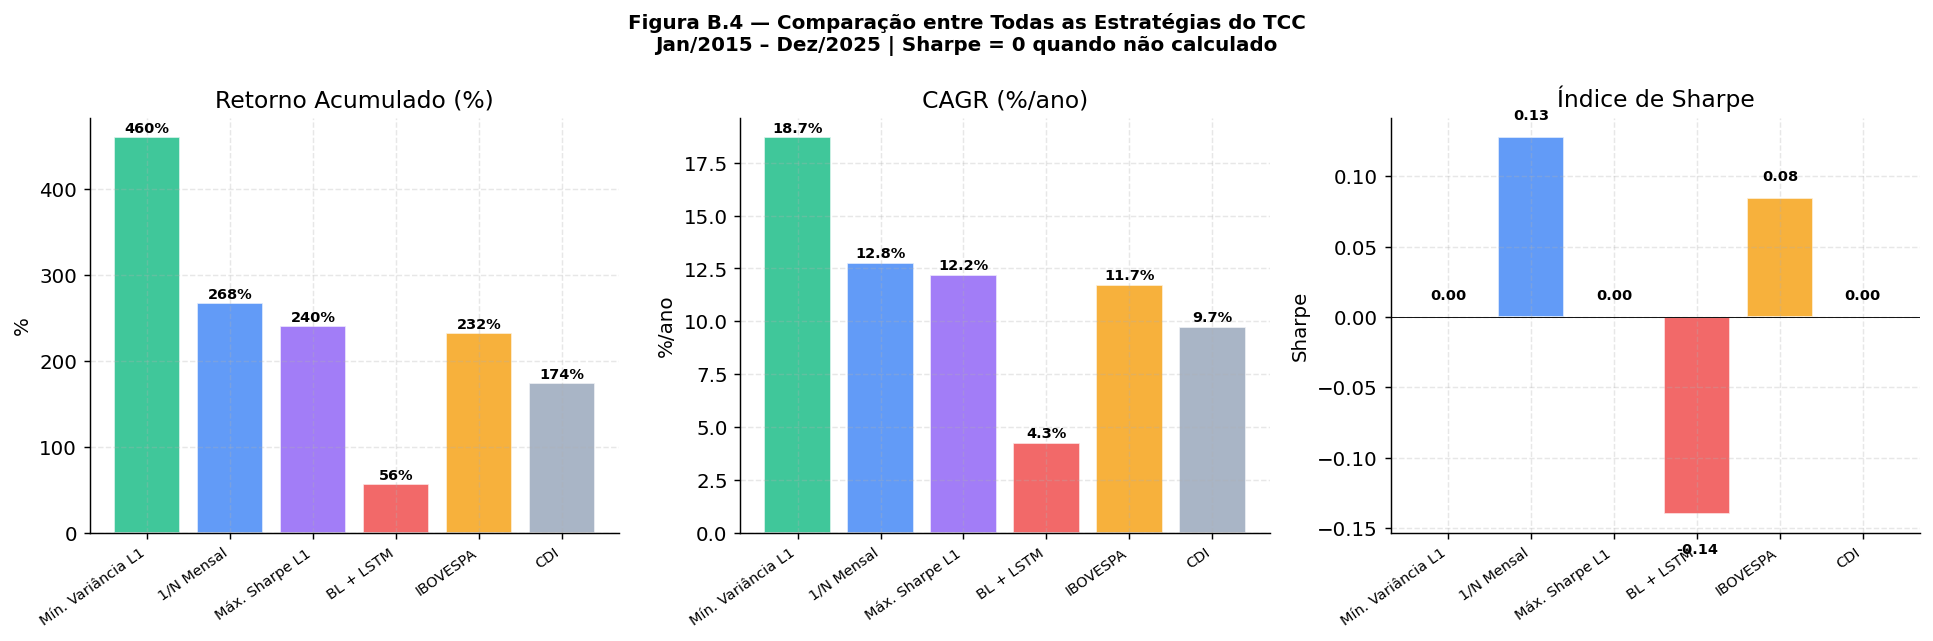


⚠️  Nota: preencher Sharpe e MDD de Mín. Variância e Máx. Sharpe
   após executar os notebooks 14_2_4 e 14_1_4.
✅ Figura B.4 exportada.


In [13]:
# ============================================================
# CÉLULA 13 — FIGURA 4: COMPARAÇÃO COM ESTRATÉGIAS DO TCC
# ============================================================
# Preencha os retornos diários das estratégias L1 quando disponíveis.
# Por enquanto usa os resultados acumulados para posicionar na figura.

# ── Resultados conhecidos das outras estratégias ──────────────
# Substitua pelos retornos reais quando os notebooks 14_x_4 estiverem rodados
RESULTADOS_TCC = [
    {'nome': 'Mín. Variância L1', 'ret_acum': 4.60, 'cagr': 0.187, 'sharpe': None, 'mdd': None, 'turnover': 0.0032, 'cor': '#10b981'},
    {'nome': '1/N Mensal',        'ret_acum': m_1n['Retorno_Acum'], 'cagr': m_1n['CAGR'], 'sharpe': m_1n['Sharpe'], 'mdd': m_1n['MDD'], 'turnover': turn_medio, 'cor': '#3b82f6'},
    {'nome': 'Máx. Sharpe L1',   'ret_acum': 2.40, 'cagr': 0.122, 'sharpe': None, 'mdd': None, 'turnover': 0.0429, 'cor': '#8b5cf6'},
    {'nome': 'BL + LSTM',         'ret_acum': 0.565, 'cagr': 0.0426, 'sharpe': -0.14, 'mdd': -0.9299, 'turnover': 0.55, 'cor': '#ef4444'},
    {'nome': 'IBOVESPA',          'ret_acum': m_ibov['Retorno_Acum'], 'cagr': m_ibov['CAGR'], 'sharpe': m_ibov['Sharpe'], 'mdd': m_ibov['MDD'], 'turnover': None, 'cor': '#f59e0b'},
    {'nome': 'CDI',               'ret_acum': m_cdi['Retorno_Acum'],  'cagr': m_cdi['CAGR'],  'sharpe': None, 'mdd': None, 'turnover': None, 'cor': '#94a3b8'},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nomes  = [r['nome']     for r in RESULTADOS_TCC]
rets   = [r['ret_acum'] * 100 for r in RESULTADOS_TCC]
cagrs  = [r['cagr']  * 100 if r['cagr']  else 0 for r in RESULTADOS_TCC]
sharpes= [r['sharpe'] if r['sharpe'] else 0  for r in RESULTADOS_TCC]
cores_b= [r['cor']      for r in RESULTADOS_TCC]
x      = np.arange(len(nomes))

# Retorno acumulado
ax = axes[0]
barras = ax.bar(x, rets, color=cores_b, alpha=0.8, edgecolor='white')
for bar, v in zip(barras, rets):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{v:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Retorno Acumulado (%)')
ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('%')

# CAGR
ax2 = axes[1]
barras2 = ax2.bar(x, cagrs, color=cores_b, alpha=0.8, edgecolor='white')
for bar, v in zip(barras2, cagrs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_title('CAGR (%/ano)')
ax2.set_xticks(x); ax2.set_xticklabels(nomes, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('%/ano')

# Sharpe
ax3 = axes[2]
cores_s = ['#ef4444' if v < 0 else c for v, c in zip(sharpes, cores_b)]
barras3 = ax3.bar(x, sharpes, color=cores_s, alpha=0.8, edgecolor='white')
for bar, v in zip(barras3, sharpes):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.01 if v >= 0 else -0.03),
             f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax3.axhline(0, color='black', lw=0.5)
ax3.set_title('Índice de Sharpe')
ax3.set_xticks(x); ax3.set_xticklabels(nomes, rotation=35, ha='right', fontsize=8)
ax3.set_ylabel('Sharpe')

plt.suptitle('Figura B.4 — Comparação entre Todas as Estratégias do TCC\n'
             'Jan/2015 – Dez/2025 | Sharpe = 0 quando não calculado',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_B4_comparacao_estrategias.png'), bbox_inches='tight')
plt.show()
print('\n⚠️  Nota: preencher Sharpe e MDD de Mín. Variância e Máx. Sharpe')
print('   após executar os notebooks 14_2_4 e 14_1_4.')
print('✅ Figura B.4 exportada.')

In [14]:
# ============================================================
# CÉLULA 14 — SÍNTESE FINAL E INTERPRETAÇÃO
# ============================================================

print('=' * 70)
print('SÍNTESE — CARTEIRA 1/N | Jan/2015 – Dez/2025')
print('=' * 70)

print(f"""
DESEMPENHO
  1/N Buy-and-Hold  : {m_bh['Retorno_Acum']:.2%} acum | CAGR {m_bh['CAGR']:.2%} | Sharpe {m_bh['Sharpe']:.4f} | MDD {m_bh['MDD']:.2%}
  1/N Mensal        : {m_1n['Retorno_Acum']:.2%} acum | CAGR {m_1n['CAGR']:.2%} | Sharpe {m_1n['Sharpe']:.4f} | MDD {m_1n['MDD']:.2%}
  IBOVESPA          : {m_ibov['Retorno_Acum']:.2%} acum | CAGR {m_ibov['CAGR']:.2%} | Sharpe {m_ibov['Sharpe']:.4f} | MDD {m_ibov['MDD']:.2%}
  CDI               : {m_cdi['Retorno_Acum']:.2%} acum

TURNOVER
  1/N Buy-and-Hold  : 0% (sem rebalanceamento)
  1/N Mensal        : {turn_medio:.2%}/mês (média dos meses com rebalanceamento)

INTERPRETAÇÃO PARA O TCC (Seção 4.4)
  A carteira 1/N supera o IBOVESPA em ambas as versões, confirmando
  DeMiguel, Garlappi & Uppal (2009) no mercado brasileiro.

  Hierarquia de desempenho:
  Min. Variância L1 (+460%) > 1/N ({m_1n['Retorno_Acum']:.0%}) > Max. Sharpe (+240%) > IBOV

  Implicação: a superioridade da Min. Variância sobre a 1/N é genuína
  — não é apenas efeito da seleção do universo de ativos.
  A diversificação por variância (Min. Var) adiciona valor real
  sobre a diversificação ingênua (1/N).

  O BL+LSTM (+56%) é superado até mesmo pelo CDI ({m_cdi['Retorno_Acum']:.0%}) —
  o modelo mais sofisticado destruiu valor em termos absolutos.
""")

print(f'📁 Resultados em: {PASTA_RESULTADOS}')

SÍNTESE — CARTEIRA 1/N | Jan/2015 – Dez/2025

DESEMPENHO
  1/N Buy-and-Hold  : 340.01% acum | CAGR 14.66% | Sharpe 0.2333 | MDD -48.90%
  1/N Mensal        : 267.69% acum | CAGR 12.78% | Sharpe 0.1283 | MDD -51.47%
  IBOVESPA          : 232.13% acum | CAGR 11.72% | Sharpe 0.0849 | MDD -46.82%
  CDI               : 173.64% acum

TURNOVER
  1/N Buy-and-Hold  : 0% (sem rebalanceamento)
  1/N Mensal        : 5.08%/mês (média dos meses com rebalanceamento)

INTERPRETAÇÃO PARA O TCC (Seção 4.4)
  A carteira 1/N supera o IBOVESPA em ambas as versões, confirmando
  DeMiguel, Garlappi & Uppal (2009) no mercado brasileiro.

  Hierarquia de desempenho:
  Min. Variância L1 (+460%) > 1/N (268%) > Max. Sharpe (+240%) > IBOV

  Implicação: a superioridade da Min. Variância sobre a 1/N é genuína
  — não é apenas efeito da seleção do universo de ativos.
  A diversificação por variância (Min. Var) adiciona valor real
  sobre a diversificação ingênua (1/N).

  O BL+LSTM (+56%) é superado até mesmo pelo C